What Jordan was finding - some way to store the previous information being processed at t moving towards left side from current t. But we need memory for this information to store , eventual ideas of feeding the inputs failed as the input size will grow expononentially over time.Here Jordan proposed that why dont we use the previvous information stored in a so called memory **state** to be --- but the question still remains where and what are we storing ? **Jordan** answered this !

See we had many options like : inputs,outpus,hidden layers outpus from activation functions,state or everything .Then how did we even choose the best thing from this ?
Jordan proposed that why dont we just pass the output of the previous network to the next network at time = **t+1**.


To understand exactly how data moves through a Jordan Network during a single epoch, we can trace the mathematical transformations step-by-step.

Below is the complete mathematical blueprint for **one training epoch** across $T = 3$ time steps. This covers the initialization, the Forward Pass, the calculation of Total Loss, and the **Backpropagation Through Time (BPTT)** gradient derivations.

---

### 🧮 Mathematical Components

#### The Variables & Vectors
*   $\mathbf{p} \in \mathbb{R}^{4 \times 1}$: Static Plan vector (constant across all time steps).
*   $\mathbf{c}_t \in \mathbb{R}^{3 \times 1}$ : Context (State) vector at time $t$.
*   $\mathbf{h}_t \in \mathbb{R}^{8 \times 1}$: Hidden layer activation vector at time $t$.
*   $\mathbf{y}_t \in \mathbb{R}^{3 \times 1}$: Output layer activation vector at time $t$.
*   $\hat{\mathbf{y}}_t \in \mathbb{R}^{3 \times 1}$: Target output vector at time $t$.

#### The Parameters (Weights & Biases)
*   $\mathbf{W}_{xh} \in \mathbb{R}^{8 \times 4}$ (Plan to Hidden)
*   $\mathbf{W}_{ch} \in \mathbb{R}^{8 \times 3}$ (Context to Hidden)
*   $\mathbf{W}_{ho} \in \mathbb{R}^{3 \times 8}$ (Hidden to Output)
*   $\mathbf{b}_h \in \mathbb{R}^{8 \times 1}$ (Hidden Bias), $\quad \mathbf{b}_o \in \mathbb{R}^{3 \times 1}$ (Output Bias)
*   $\alpha \in \mathbb{R}$: Scalar decay constant ($0.4$).

#### The Element-wise Activation Functions
*   $\sigma(\mathbf{z}) = \frac{1}{1 + e^{-\mathbf{z}}}$
*   $\sigma'(\mathbf{z}) = \sigma(\mathbf{z}) \odot (1 - \sigma(\mathbf{z})) \quad$ (where $\odot$ is the专 Hadamard element-wise product).

---

### 🔀 Phase 1: Forward Pass

#### Initialization ($t = 0$)
$$\mathbf{c}_0 = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}, \quad \mathbf{y}_0 = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$

---

#### ⏱️ Time Step $t = 1$

##### 1. Context Update
$$\mathbf{c}_1 = \mathbf{y}_0 + \alpha \mathbf{c}_0 = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$

##### 2. Hidden Layer Forward
$$\mathbf{z}_{h,1} = \mathbf{W}_{xh}\mathbf{p} + \mathbf{W}_{ch}\mathbf{c}_1 + \mathbf{b}_h$$
$$\mathbf{h}_1 = \sigma(\mathbf{z}_{h,1})$$

##### 3. Output Layer Forward
$$\mathbf{z}_{o,1} = \mathbf{W}_{ho}\mathbf{h}_1 + \mathbf{b}_o$$
$$\mathbf{y}_1 = \sigma(\mathbf{z}_{o,1})$$

---

#### ⏱️ Time Step $t = 2$

##### 1. Context Update (Jordan Feedback Loop)
$$\mathbf{c}_2 = \mathbf{y}_1 + \alpha \mathbf{c}_1 = \mathbf{y}_1$$

##### 2. Hidden Layer Forward
$$\mathbf{z}_{h,2} = \mathbf{W}_{xh}\mathbf{p} + \mathbf{W}_{ch}\mathbf{c}_2 + \mathbf{b}_h$$
$$\mathbf{h}_2 = \sigma(\mathbf{z}_{h,2})$$

##### 3. Output Layer Forward
$$\mathbf{z}_{o,2} = \mathbf{W}_{ho}\mathbf{h}_2 + \mathbf{b}_o$$
$$\mathbf{y}_2 = \sigma(\mathbf{z}_{o,2})$$

---

#### ⏱️ Time Step $t = 3$

##### 1. Context Update
$$\mathbf{c}_3 = \mathbf{y}_2 + \alpha \mathbf{c}_2 = \mathbf{y}_2 + \alpha \mathbf{y}_1$$

##### 2. Hidden Layer Forward
$$\mathbf{z}_{h,3} = \mathbf{W}_{xh}\mathbf{p} + \mathbf{W}_{ch}\mathbf{c}_3 + \mathbf{b}_h$$
$$\mathbf{h}_3 = \sigma(\mathbf{z}_{h,3})$$

##### 3. Output Layer Forward
$$\mathbf{z}_{o,3} = \mathbf{W}_{ho}\mathbf{h}_3 + \mathbf{b}_o$$
$$\mathbf{y}_3 = \sigma(\mathbf{z}_{o,3})$$

---

### 🎯 Phase 2: Total Loss Calculation
Using the Mean Squared Error (MSE) over the entire generated trajectory:
$$\mathcal{L}_{total} = \sum_{t=1}^{3} \mathcal{L}_t = \sum_{t=1}^{3} \frac{1}{2} \Vert{}\mathbf{y}_t - \hat{\mathbf{y}}_t\Vert{}^2_2$$

---

### ↩️ Phase 3: Backward Pass (BPTT)

To update weights, we compute the gradient of the total loss by calculating local errors ($\mathbf{\delta}_o$ and $\mathbf{\delta}_h$) at each time step, unrolling backwards from $t=3$ to $t=1$.

#### ⏱️ Step $t = 3$

##### 1. Output Error Gradient
$$\mathbf{\delta}_{o,3} = \frac{\partial \mathcal{L}_{total}}{\partial \mathbf{z}_{o,3}} = (\mathbf{y}_3 - \hat{\mathbf{y}}_3) \odot \sigma'(\mathbf{z}_{o,3})$$

##### 2. Parameter Accumulation at $t=3$
$$\frac{\partial \mathcal{L}_3}{\partial \mathbf{W}_{ho}} = \mathbf{\delta}_{o,3} \mathbf{h}_3^T, \quad \frac{\partial \mathcal{L}_3}{\partial \mathbf{b}_o} = \mathbf{\delta}_{o,3}$$

##### 3. Hidden Error Gradient
$$\mathbf{\delta}_{h,3} = \frac{\partial \mathcal{L}_{total}}{\partial \mathbf{z}_{h,3}} = \left( \mathbf{W}_{ho}^T \mathbf{\delta}_{o,3} \right) \odot \sigma'(\mathbf{z}_{h,3})$$

##### 4. Parameter Accumulation at $t=3$
$$\frac{\partial \mathcal{L}_3}{\partial \mathbf{W}_{xh}} = \mathbf{\delta}_{h,3} \mathbf{p}^T, \quad \frac{\partial \mathcal{L}_3}{\partial \mathbf{W}_{ch}} = \mathbf{\delta}_{h,3} \mathbf{c}_3^T, \quad \frac{\partial \mathcal{L}_3}{\partial \mathbf{b}_h} = \mathbf{\delta}_{h,3}$$

---

#### ⏱️ Step $t = 2$
*Note: Because $\mathbf{y}_2$ directly feeds into $\mathbf{c}_3$, the error at $t=2$ must include the incoming gradient from the future hidden layer ($\mathbf{h}_3$).*

##### 1. Output Error Gradient (incorporating the future temporal connection)
$$\mathbf{\delta}_{o,2} = \left[ (\mathbf{y}_2 - \hat{\mathbf{y}}_2) + \mathbf{W}_{ch}^T \mathbf{\delta}_{h,3} \right] \odot \sigma'(\mathbf{z}_{o,2})$$

##### 2. Parameter Accumulation at $t=2$
$$\frac{\partial \mathcal{L}_2}{\partial \mathbf{W}_{ho}} += \mathbf{\delta}_{o,2} \mathbf{h}_2^T, \quad \frac{\partial \mathcal{L}_2}{\partial \mathbf{b}_o} += \mathbf{\delta}_{o,2}$$

##### 3. Hidden Error Gradient
$$\mathbf{\delta}_{h,2} = \left( \mathbf{W}_{ho}^T \mathbf{\delta}_{o,2} \right) \odot \sigma'(\mathbf{z}_{h,2})$$

##### 4. Parameter Accumulation at $t=2$
$$\frac{\partial \mathcal{L}_2}{\partial \mathbf{W}_{xh}} += \mathbf{\delta}_{h,2} \mathbf{p}^T, \quad \frac{\partial \mathcal{L}_2}{\partial \mathbf{W}_{ch}} += \mathbf{\delta}_{h,2} \mathbf{c}_2^T, \quad \frac{\partial \mathcal{L}_2}{\partial \mathbf{b}_h} += \mathbf{\delta}_{h,2}$$

---

#### ⏱️ Step $t = 1$
*Note: $\mathbf{y}_1$ affects $\mathbf{c}_2$ directly, and affects $\mathbf{c}_3$ via decay ($\alpha$). This unrolls upstream.*

##### 1. Output Error Gradient
$$\mathbf{\delta}_{o,1} = \left[ (\mathbf{y}_1 - \hat{\mathbf{y}}_1) + \mathbf{W}_{ch}^T \mathbf{\delta}_{h,2} + \alpha \mathbf{W}_{ch}^T \mathbf{\delta}_{h,3} \right] \odot \sigma'(\mathbf{z}_{o,1})$$

##### 2. Parameter Accumulation at $t=1$
$$\frac{\partial \mathcal{L}_1}{\partial \mathbf{W}_{ho}} += \mathbf{\delta}_{o,1} \mathbf{h}_1^T, \quad \frac{\partial \mathcal{L}_1}{\partial \mathbf{b}_o} += \mathbf{\delta}_{o,1}$$

##### 3. Hidden Error Gradient
$$\mathbf{\delta}_{h,1} = \left( \mathbf{W}_{ho}^T \mathbf{\delta}_{o,1} \right) \odot \sigma'(\mathbf{z}_{h,1})$$

##### 4. Parameter Accumulation at $t=1$
$$\frac{\partial \mathcal{L}_1}{\partial \mathbf{W}_{xh}} += \mathbf{\delta}_{h,1} \mathbf{p}^T, \quad \frac{\partial \mathcal{L}_1}{\partial \mathbf{W}_{ch}} += \mathbf{\delta}_{h,1} \mathbf{c}_1^T, \quad \frac{\partial \mathcal{L}_1}{\partial \mathbf{b}_h} += \mathbf{\delta}_{h,1}$$

---

### 📉 Phase 4: Gradient Descent Weight Update
At the very end of the epoch, the total accumulated gradients are subtracted from the parameter matrices using the learning rate $\eta$:

$$\mathbf{W}_{ho} \leftarrow \mathbf{W}_{ho} - \eta \sum_{t=1}^{3} \frac{\partial \mathcal{L}_t}{\partial \mathbf{W}_{ho}} \quad\quad \mathbf{b}_o \leftarrow \mathbf{b}_o - \eta \sum_{t=1}^{3} \frac{\partial \mathcal{L}_t}{\partial \mathbf{b}_o}$$

$$\mathbf{W}_{xh} \leftarrow \mathbf{W}_{xh} - \eta \sum_{t=1}^{3} \frac{\partial \mathcal{L}_t}{\partial \mathbf{W}_{xh}} \quad\quad \mathbf{b}_h \leftarrow \mathbf{b}_h - \eta \sum_{t=1}^{3} \frac{\partial \mathcal{L}_t}{\partial \mathbf{b}_h}$$

$$\mathbf{W}_{ch} \leftarrow \mathbf{W}_{ch} - \eta \sum_{t=1}^{3} \frac{\partial \mathcal{L}_t}{\partial \mathbf{W}_{ch}}$$


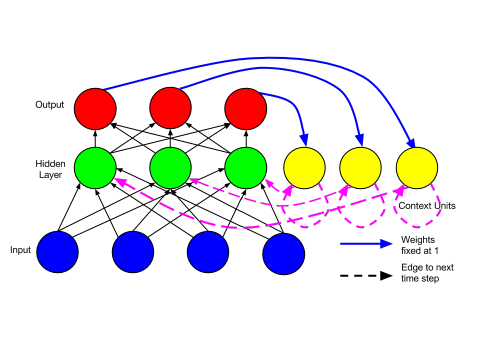

In [7]:
import numpy as np


In [8]:
# 1. Setup dimensions and hyper-parameters
plan_dim = 4      # Size of the static Plan vector
context_dim = 3   # Size of context units (MUST equal output_dim)
hidden_dim = 8    # Size of hidden units
output_dim = 3    # Size of output units

alpha = 0.4       # Context decay factor (Jordan's self-feedback)
lr = 0.3          # Learning rate
epochs = 3000

# 2. Initialize trainable parameters randomly
np.random.seed(1)
W_xh = np.random.randn(hidden_dim, plan_dim) * 0.5   # Plan to Hidden
W_ch = np.random.randn(hidden_dim, context_dim) * 0.5 # Context to Hidden
W_ho = np.random.randn(output_dim, hidden_dim) * 0.5   # Hidden to Output

b_h = np.zeros((hidden_dim, 1))
b_o = np.zeros((output_dim, 1))

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# 3. Define the experiment: 1 Static Plan mapping to a 3-step sequence trajectory
plan = np.array([[1], [0], [0], [1]])
targets = [
    np.array([[0.9], [0.1], [0.1]]), # Target sequence step 1
    np.array([[0.1], [0.9], [0.1]]), # Target sequence step 2
    np.array([[0.1], [0.1], [0.9]])  # Target sequence step 3
]


In [9]:
# 4. Training Loop
for epoch in range(epochs):
    # Initialize states at t=0
    context = np.zeros((context_dim, 1))
    prev_output = np.zeros((output_dim, 1))

    # Track states per step for backpropagation
    contexts, hiddens, outputs = [context], [], []

    # --- Forward Pass ---
    for t in range(len(targets)):
        # Jordan Recurrent Equation: C_t = Y_{t-1} + alpha * C_{t-1}
        context = prev_output + alpha * context
        contexts.append(context)

        # Process Hidden Layer
        hidden = sigmoid(np.dot(W_xh, plan) + np.dot(W_ch, context) + b_h)
        hiddens.append(hidden)

        # Process Output Layer
        output = sigmoid(np.dot(W_ho, hidden) + b_o)
        outputs.append(output)

        # Cache current output to act as the feedback trigger for next time-step
        prev_output = output

    # --- Backward Pass (BPTT) ---
    dW_xh, dW_ch, dW_ho = np.zeros_like(W_xh), np.zeros_like(W_ch), np.zeros_like(W_ho)
    db_h, db_o = np.zeros_like(b_h), np.zeros_like(b_o)

    # Travel backwards in time to compute gradients
    for t in reversed(range(len(targets))):
        error = outputs[t] - targets[t]

        # Output layer gradients
        d_output = error * sigmoid_derivative(outputs[t])
        dW_ho += np.dot(d_output, hiddens[t].T)
        db_o += d_output

        # Hidden layer gradients
        d_hidden = np.dot(W_ho.T, d_output) * sigmoid_derivative(hiddens[t])
        dW_xh += np.dot(d_hidden, plan.T)
        dW_ch += np.dot(d_hidden, contexts[t+1].T) # context index matches offset
        db_h += d_hidden

    # Gradient Descent parameter update step
    W_xh -= lr * dW_xh
    W_ch -= lr * dW_ch
    W_ho -= lr * dW_ho
    b_h -= lr * db_h
    b_o -= lr * db_o

# 5. Execution Test: Generate the trajectory using the trained network
print("--- Trained Jordan Network Sequence Execution ---")
context = np.zeros((context_dim, 1))
prev_output = np.zeros((output_dim, 1))

for t in range(len(targets)):
    context = prev_output + alpha * context
    hidden = sigmoid(np.dot(W_xh, plan) + np.dot(W_ch, context) + b_h)
    output = sigmoid(np.dot(W_ho, hidden) + b_o)
    print(f"Time Step {t+1}: Predicted {output.flatten().round(2)} | Target {targets[t].flatten()}")
    prev_output = output

--- Trained Jordan Network Sequence Execution ---
Time Step 1: Predicted [0.9 0.1 0.1] | Target [0.9 0.1 0.1]
Time Step 2: Predicted [0.1 0.9 0.1] | Target [0.1 0.9 0.1]
Time Step 3: Predicted [0.1 0.1 0.9] | Target [0.1 0.1 0.9]


In your Hopfield experiment, the network was purely static. It looked at an image pattern, iterated until it settled into an attractor, and stopped.Here, even if Time Step 1 and Time Step 3 had the exact same external inputs, the network's hidden layer would calculate completely different outputs because the Old State (Memory) is radically different. The network now knows when it is in the timeline.